# Эксперимент A: качество планировщика

Вопрос: насколько прогноз медиаплана (расход и KPI на конец кампании) совпадает с фактом, если план исполняется **замороженно** (frozen) — без перераспределения. Так измеряется именно планировщик, трафик-менеджер выключен.

- Метрика: `dev = (fact − plan) / plan` на последнем часе кампании, отдельно по расходу и KPI. Порог кейса — 20 % по модулю.
- Миры: `world_seed` 1–8 сегментированного симулятора, кампанийные сиды 1–2, случайные события мира выключены.
- Источник знаний: `history N` — план построен по N прошлым кампаниям на том же мире (0 = только публичный каталог). Прошлые кампании спланированы optimized и исполнены frozen.
- Факторы: KPI (конверсии / клики / охват), бюджет (0,5 / 1,2 / 3 млн), горизонт (14 / 21 д), стратегия (optimized / uniform), стиль прогрева, задача B (цель → бюджет).

### Замечания к дизайну (что ещё не покрыто)

- **Метрика.** `|dev|` — модуль отклонения одного прогона (APE). MAPE — это среднее `|dev|` по прогонам группы; в таблицах вместо среднего даны медиана и p90, потому что среднее тянут выбросы, а p90 напрямую отвечает на вопрос «укладываемся ли в 20 %». В базовой ячейке MAPE и медиана почти совпадают: 28,6 / 25,7 % без истории, 7–9 / 7–10 % с историей. Поле `mape_kpi` в сырых данных — другое: среднее по часам траектории одного прогона.
- **Сетка не полная.** Бюджет варьируется только при 21 дне (конверсии и клики), горизонт — только при 1,2 млн и только для конверсий, всего две точки; охват есть только в базовой ячейке. Это «один фактор за раз» вокруг брифа кейса. Полный факториал KPI × бюджет (0,3–5 млн) × горизонт (7–30 д) × история — около 60 ячеек и час-полтора счёта, нужен для тепловой карты «бюджет × горизонт».
- **Мир тихий.** Случайные события симулятора (дрейф спроса и CPM, спонтанные шоки) выключены в оцениваемых кампаниях, но включены в прогревочных. Сценарные шоки (CTR −40 %, CPM +60 %, спрос −50 %, пауза) здесь не запускались. Планируемая ось волатильности: тихий мир / штатный шум (случайные события включены) / жёсткий мир (конфиг с удвоенными сигмами и вероятностями шоков) плюс четыре сценарных шока под frozen. Ошибка на шоках после t0 — не дефект планировщика, а граница, за которой работает трафик-менеджер (эксперимент B).


In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS = Path('.').resolve() / 'planner'
if not (RESULTS / 'all_runs.json').exists():
    RESULTS = Path('media_planner/tools/evaluation/results/planner')
FIG = RESULTS.parent / 'figures'; FIG.mkdir(exist_ok=True)
runs = pd.DataFrame(json.load(open(RESULTS / 'all_runs.json')))
runs['abs_kpi'] = runs.final_dev_kpi.abs(); runs['abs_spend'] = runs.final_dev_spend.abs()
KPI_RU = {'conversions': 'конверсии', 'clicks': 'клики', 'unique_reach': 'охват'}
def table(df, by):
    g = df.groupby(by)
    out = pd.DataFrame({
        'прогонов': g.size(),
        'dev расход p50': g.final_dev_spend.median(),
        'dev KPI p50': g.final_dev_kpi.median(),
        '|dev KPI| p50': g.abs_kpi.median(),
        '|dev KPI| p90': g.abs_kpi.quantile(0.9),
        'в пределах 20 %': g.within_20.mean(),
    })
    return out.style.format({c: '{:+.1%}' for c in out.columns if c.startswith('dev')} | {c: '{:.1%}' for c in ['|dev KPI| p50', '|dev KPI| p90', 'в пределах 20 %']})
print(len(runs), 'прогонов,', runs.cell.nunique(), 'ячеек')

400 прогонов, 12 ячеек


## 1. Источник знаний: каталог против истории (конверсии, 1,2 млн, 21 д)

In [2]:
core = runs[runs.cell == 'core-conversions-1.2M']
table(core, 'history')

,прогонов,dev расход p50,dev KPI p50,|dev KPI| p50,|dev KPI| p90,в пределах 20 %
history,,,,,,
0,16,-0.1%,+5.3%,25.7%,48.4%,37.5%
1,16,-0.1%,-7.6%,8.0%,13.2%,100.0%
3,16,-0.0%,-0.4%,10.2%,13.4%,100.0%
5,16,-0.1%,-3.6%,6.9%,12.8%,100.0%


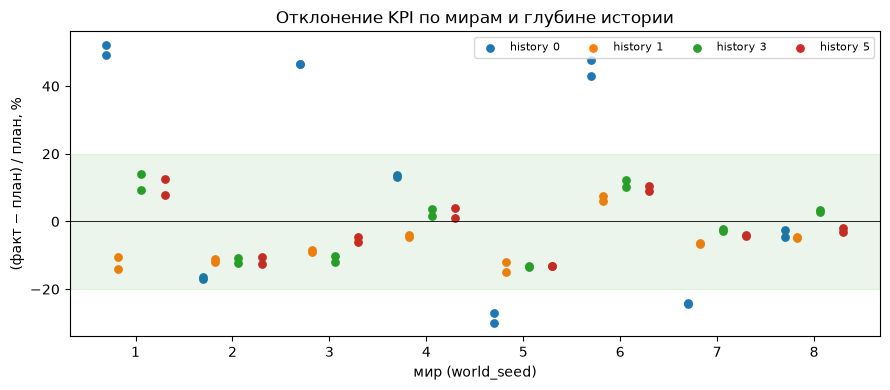

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
for h, sub in core.groupby('history'):
    ax.scatter(sub.world_seed + (h - 2.5) * 0.12, sub.final_dev_kpi * 100, label=f'history {h}', s=28)
ax.axhspan(-20, 20, color='green', alpha=0.08); ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('мир (world_seed)'); ax.set_ylabel('(факт − план) / план, %'); ax.set_title('Отклонение KPI по мирам и глубине истории')
ax.legend(ncol=4, fontsize=8); fig.tight_layout(); fig.savefig(FIG / 'planner_knowledge_by_world.png', dpi=120)

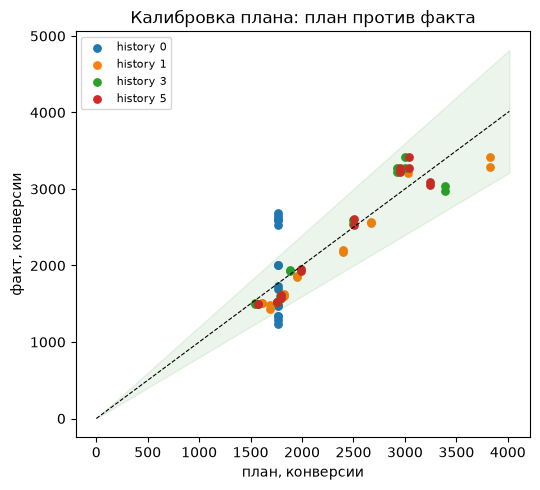

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 5))
for h, sub in core.groupby('history'):
    ax.scatter(sub.plan_kpi, sub.fact_kpi, label=f'history {h}', s=28)
lim = [0, max(core.plan_kpi.max(), core.fact_kpi.max()) * 1.05]
ax.plot(lim, lim, 'k--', lw=0.8); ax.fill_between(lim, [l * 0.8 for l in lim], [l * 1.2 for l in lim], color='green', alpha=0.08)
ax.set_xlabel('план, конверсии'); ax.set_ylabel('факт, конверсии'); ax.set_title('Калибровка плана: план против факта'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / 'planner_calibration.png', dpi=120)

## 2. Вид KPI (1,2 млн, 21 д)

In [5]:
kpi = runs[runs.cell.str.startswith('core-') & runs.history.isin([0, 3])].copy()
kpi['KPI'] = kpi.optimize.map(KPI_RU)
table(kpi, ['KPI', 'history'])

## 3. Бюджет (21 д, optimized)

In [6]:
bud = runs[(runs.strategy == 'optimized') & runs.target.isna() & (runs.days == 21) & (runs.history_mode == 'frozen') & runs.optimize.isin(['conversions', 'clicks']) & runs.history.isin([0, 3])].copy()
bud['KPI'] = bud.optimize.map(KPI_RU); bud['бюджет, млн'] = bud.budget_level / 1e6
table(bud, ['KPI', 'бюджет, млн', 'history'])

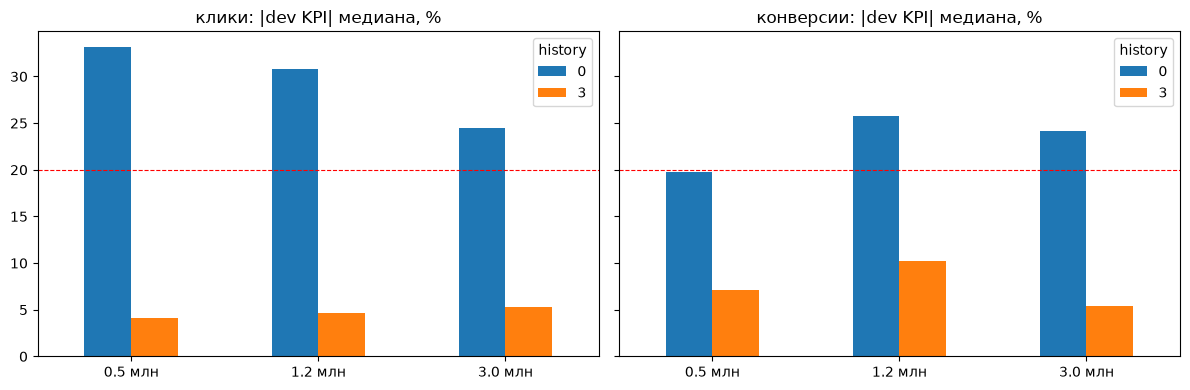

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (o, sub) in zip(axes, bud.groupby('optimize')):
    piv = sub.groupby(['budget_level', 'history']).abs_kpi.median().unstack('history') * 100
    piv.index = [f'{b/1e6:.1f} млн' for b in piv.index]
    piv.plot.bar(ax=ax, rot=0); ax.axhline(20, color='r', ls='--', lw=0.8); ax.set_title(f'{KPI_RU[o]}: |dev KPI| медиана, %'); ax.set_xlabel('')
fig.tight_layout(); fig.savefig(FIG / 'planner_budget.png', dpi=120)

## 4. Горизонт, стратегия и стиль прогрева (конверсии, 1,2 млн)

In [8]:
hz = runs[(runs.optimize == 'conversions') & (runs.budget_level == 1_200_000) & (runs.strategy == 'optimized') & runs.target.isna() & (runs.history_mode == 'frozen') & runs.history.isin([0, 3])]
display(table(hz, ['days', 'history']))
st = runs[runs.cell.isin(['core-conversions-1.2M', 'uniform-conversions-1.2M']) & runs.history.isin([0, 3])]
display(table(st, ['strategy', 'history']))
wu = runs[(runs.optimize == 'conversions') & (runs.budget_level == 1_200_000) & (runs.days == 21) & (runs.strategy == 'optimized') & runs.target.isna() & (runs.history == 3)]
table(wu, 'history_mode')

,прогонов,dev расход p50,dev KPI p50,|dev KPI| p50,|dev KPI| p90,в пределах 20 %
history_mode,,,,,,
frozen,16,-0.0%,-0.4%,10.2%,13.4%,100.0%
uniform,16,-0.1%,-4.1%,4.9%,12.4%,100.0%


## 5. Задача B: цель → минимальный бюджет → замороженное исполнение

`fact / target` > 1 — планировщик зарезервировал больше бюджета, чем нужно; < 1 — цели не достигли.

In [9]:
tb = runs[runs.target.notna()].copy()
tb['ratio'] = tb.fact_kpi / tb.target
g = tb.groupby(['cell', 'history'])
pd.DataFrame({'прогонов': g.size(), 'цель достигнута': g.ratio.apply(lambda s: (s >= 1).mean()), 'факт/цель p50': g.ratio.median(), 'факт/цель p10': g.ratio.quantile(0.1), 'факт/цель p90': g.ratio.quantile(0.9), 'бюджет p50': g.required_budget.median()}).style.format({'цель достигнута': '{:.0%}', 'факт/цель p50': '{:.2f}', 'факт/цель p10': '{:.2f}', 'факт/цель p90': '{:.2f}', 'бюджет p50': '{:,.0f}'})

## 6. Разложение ошибки по каналам (конверсии, 1,2 млн, 21 д)

Медианы отношений факт / план по каналам, где план дал показы. Показывает, какая из величин — объём показов, CTR, CR или CPM — тянет ошибку.

In [10]:
dec = pd.DataFrame(json.load(open(RESULTS / 'decomposition.json')))
piv = dec.groupby('history')[['impressions', 'ctr', 'cr', 'cpm']].median()
piv.style.format('{:.2f}')

,impressions,ctr,cr,cpm
history,,,,
0,0.87,0.99,1.03,1.14
1,0.98,0.98,0.95,1.02
3,0.97,1.02,0.98,1.03
5,0.99,1.02,0.97,1.01


## Выводы

1. **Источник знаний — главный фактор.** По публичному каталогу план не зависит от мира (всегда ≈1770 конверсий), а факт лежит в диапазоне 1250–2700: медиана |dev KPI| 26 %, p90 48 %, в порог 20 % попадает 38 % прогонов. Уже одна прошлая кампания даёт p90 ≈13 % и 100 % попаданий; 3 и 5 кампаний ошибку заметно не снижают (p50 7–10 %).
2. **Остаток ошибки — систематический по миру, а не шум.** Миры 1 и 6 дают стабильные +10…+14 %, миры 2 и 5 — −12 % при любой глубине истории. Это несоответствие формулы усталости в модели планировщика (накопленный охват) и симулятора v2 (интенсивность по часам), а не нехватка данных.
3. **Расход прогнозируется почти точно** (|dev| < 1 %), кроме 3 млн по кликам без истории (−6 %): каталожная ёмкость каналов завышена, и бюджет не осваивается.
4. **KPI, бюджет и горизонт не меняют картину.** С историей 3 кампаний p90 по всем ячейкам 9–17 %: конверсии, клики и охват, 0,5–3 млн, 14 и 21 день — все в пороге. Без истории клики хуже всего (p50 31 %), охват лучше всего (p50 16 %, но со сдвигом −15 %: каталог завышает уникальный охват).
5. **Uniform-стратегия с историей хуже optimized** (+15 % vs −0,4 %): история описывает только каналы, в которые прошлые кампании вкладывали деньги; равномерный план тратит и на каналы, по которым знаний нет, и там прогноз снова каталожный. Прогрев uniform-кампаниями, наоборот, полезнее frozen-прогрева (p50 4,9 % против 10,2 %) — история покрывает все каналы.
6. **Задача B (цель → бюджет) — прогноз без смещения, но без запаса.** Факт / цель p50 = 1,00–1,02, поэтому цель достигается лишь в 25–62 % прогонов. С историей планировщик просит на 12–22 % меньше бюджета и ошибается вдвое реже (p90 1,13–1,14 против 1,42–1,48). Чтобы цель достигалась надёжно, к бюджету нужен запас порядка p90 ошибки прогноза (≈15 % с историей, ≈45 % без).
7. **Разложение по каналам:** без истории факт даёт на 13 % меньше показов и на 14 % дороже CPM, чем план; CTR и CR в медиане верны. С историей все четыре множителя в пределах ±3 %.
